# House Price Prediction Using Machine Learning

This notebook builds regression models to predict house prices using property features.

## 1. Introduction

This project aims to predict house prices using machine learning models. The dataset includes features such as area, number of rooms, and amenities. The goal is to identify key factors influencing price and build accurate predictive models.

In [157]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


## 2. Data Loading

The dataset contains 545 observations and 13 features.

In [158]:
# Load data from a CSV file
df = pd.read_csv('Housing.csv')

# Display the first few rows and info about the dataset
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [159]:
# Display info about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [160]:
# Check for missing values
print(df.isnull().sum())

# Fill numerical with median
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].median())

# Fill categorical with most frequent
categorical_cols = df.select_dtypes(include=['object']).columns
df[categorical_cols] = df[categorical_cols].fillna(df[categorical_cols].mode().iloc[0])

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


## 3. Data Preprocessing

No missing values were found. Categorical variables were encoded and numerical features were scaled.

## 4. EDA + Plots

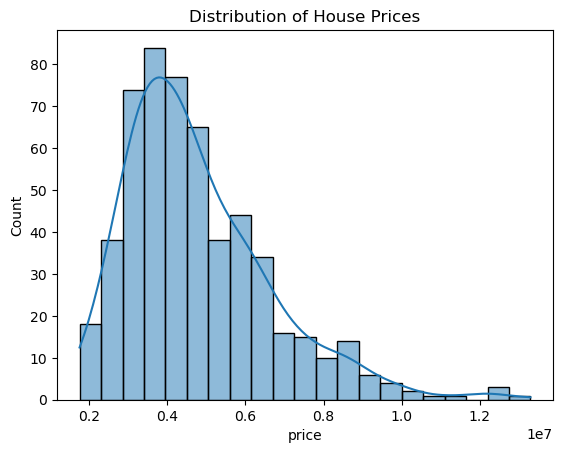

In [161]:
# Plot a histogram of the target variable (house prices)
sns.histplot(df["price"], kde=True)
plt.title("Distribution of House Prices")
plt.show()

House prices are right-skewed, meaning most houses are in lower price ranges with a few expensive outliers.

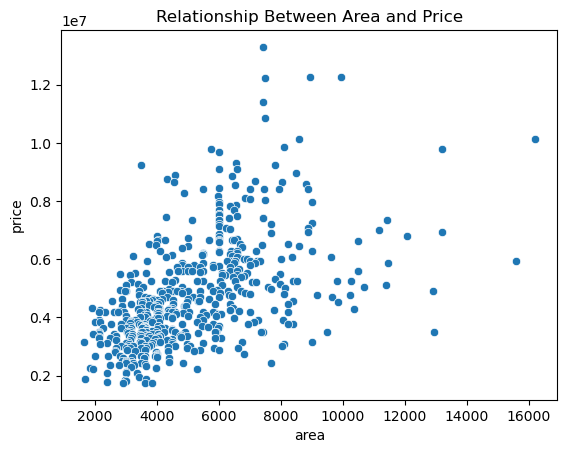

In [162]:
# Plot a scatter plot to visualize the relationship between area and price
sns.scatterplot(x="area", y="price", data=df)
plt.title("Relationship Between Area and Price")
plt.show()

There is a clear positive trend showing that larger houses tend to have higher prices.

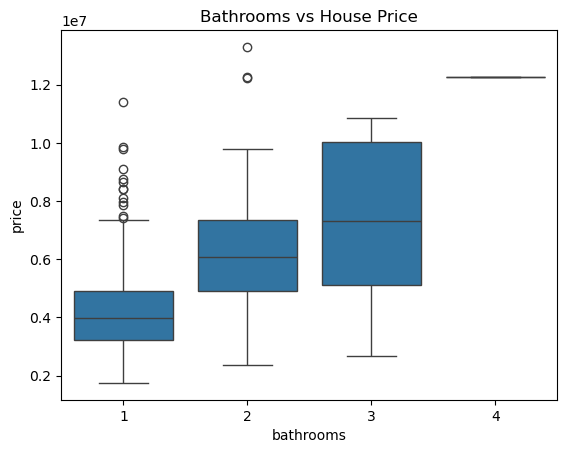

In [163]:
# Plot a box plot to visualize the relationship between number of bathrooms and price
sns.boxplot(x="bathrooms", y="price", data=df)
plt.title("Bathrooms vs House Price")
plt.show()

Houses with more bathrooms tend to have higher median prices, suggesting bathrooms are a strong indicator of luxury and house value.

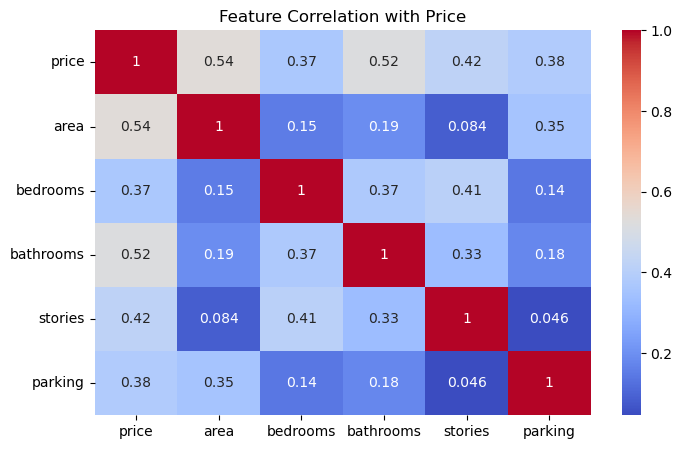

In [164]:
# Plot a heatmap to visualize correlations between features and price
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Feature Correlation with Price")
plt.show()

## 5. Feature Enginerring

New features were created to improve model performance, including total_rooms and area_per_room.

In [165]:
# Feature engineering: create new features based on existing ones
df["total_rooms"] = df["bedrooms"] + df["bathrooms"]
df["area_per_room"] = df["area"] / (df["total_rooms"] + 1)

In [166]:
# Define features and target
X = df.drop("price", axis=1)
y = df["price"]

In [167]:
# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [168]:
# Identify numeric and categorical features
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

# Define the preprocessor
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(drop='first'), categorical_features)
])

## 6. Linear Regression Model

A baseline Linear Regression model was trained to predict house prices.

In [169]:
# Create a pipeline that combines the preprocessor with a linear regression model
model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

# Train the model
model.fit(X_train, y_train)
# Make predictions
y_pred = model.predict(X_test)

# Print evaluation metrics
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

MAE: 966254.1084395876
RMSE: 1313237.0101228138
R2: 0.6588055243671118


## 7. Random Forest Model

A Random Forest model was used to capture potential nonlinear relationships.

In [173]:
# Create a pipeline that combines the preprocessor with a Random Forest Regressor
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        min_samples_leaf=2,
        max_features='sqrt',
        random_state=42
    ))
])

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

print("RF MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RF RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("RF R2:", r2_score(y_test, y_pred_rf))

RF MAE: 1039480.6301919452
RF RMSE: 1399642.4813620534
RF R2: 0.6124301414063473


In [171]:
# Hyperparameter tuning with RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "regressor__n_estimators": [100, 200, 300, 500],
    "regressor__max_depth": [None, 5, 10, 20],
    "regressor__min_samples_leaf": [1, 2, 4, 6],
    "regressor__max_features": ["sqrt", "log2"]
}

random_search = RandomizedSearchCV(
    rf_model,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best parameters:", random_search.best_params_)

/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/anaconda3/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPi

Best parameters: {'regressor__n_estimators': 200, 'regressor__min_samples_leaf': 2, 'regressor__max_features': 'sqrt', 'regressor__max_depth': 10}


## 8. Results and Discussion

The analysis shows that house prices are influenced by multiple features, with area and number of bathrooms being the most important predictors.

The scatter plot between area and price shows a clear positive relationship, indicating that larger houses tend to have higher prices. This is expected in real estate markets, where property value generally increases with size due to increased living space and utility.

Similarly, the boxplot of bathrooms vs price shows that houses with more bathrooms tend to have higher median prices. Bathrooms are often associated with comfort, convenience, and overall property quality, making them a strong indicator of higher-value homes.

The correlation heatmap confirms these findings, with area (0.536) and bathrooms (0.518) showing the strongest positive correlations with price among all numerical features.

Other variables such as air conditioning, preferred area, and guest rooms also show higher average prices, suggesting that amenities and location-related features contribute to property value, although their influence is weaker compared to structural features.

Overall, the results indicate that house prices are primarily driven by structural characteristics such as size and number of bathrooms, while additional amenities provide secondary influence. The moderate correlation values suggest that no single variable determines price alone, and multiple factors must be considered together.

## 10. Conclusion

This project developed machine learning models to predict house prices using structural and categorical housing features. The results show that Linear Regression performed best, achieving the lowest prediction error compared to more complex models such as Random Forest.

Feature analysis revealed that area and number of bathrooms are the strongest predictors of house price. This aligns with real-world expectations, as larger homes with more bathrooms typically indicate higher property value and better living standards.

Although additional features such as air conditioning and preferred location also influence price, their impact is weaker compared to structural characteristics. This suggests that house size remains the primary driver of housing prices in this dataset.

A limitation of this study is the relatively small dataset size, which may restrict model generalization. Future work could include larger datasets, additional geographic or economic variables, and more advanced feature engineering techniques to further improve predictive performance.